## Customer Churn Analytics: Business Objective


The objective of this project is to analyze telecom customer churn behavior,identify the main churn drivers and provide actionable business insights
to improve customer retention.

Dataset:
IBM Telco Customer Churn Dataset
7043 customers, 21 features

In [1]:
print("Customer Churn Analytics")

Customer Churn Analytics


Import Libraries:

In [2]:
# Data manipulation
import pandas as pd
import numpy as np
# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load telecom customer dataset
df = pd.read_csv("raw data\Telco-Customer-Churn.csv")

## Data Understanding

The first step consists of exploring the dataset structure,understanding available features and checking data quality.

The dataset contains telecom customer information and the target variable Churn indicating whether a customer left the company.

In [4]:
# Display the first rows of the dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#Dataset Dimensions:checking the number of rows and columns:number of customers and variables
df.shape

(7043, 21)

The dataset contains 7043 customers and 21 variables.

## Verify data types and structure:
The objective is to identify:
    - column data types,
    - potential inconsistencies,
    - missing values.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


We notice that the column TotalCharges was incorrectly stored as an object type instead of numeric.
Further investigation revealed hidden missing values represented by blank spaces.

Statistical Summary:Descriptive statistics are used to understand numerical variables distribution

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# Missing Values Analysis :Checking missing values in each column.
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
# Check unique values in TotalCharges
df["TotalCharges"].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      shape=(6531,), dtype=object)

In [10]:
# Detect hidden missing values represented by blank spaces
df[df["TotalCharges"] == " "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


## Data Cleaning: Handling TotalCharges Data Quality Issue

During the data quality assessment, an inconsistency was identified in the TotalCharges column.
The column was stored as object instead of numeric.Additionally, some records contained blank spaces instead of valid values.
These issues must be corrected before performing statistical analysis and machine learning.

In [11]:
# Replace blank spaces in TotalCharges with NaN values to correctly identify hidden missing data

df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)

In [12]:
# Convert TotalCharges from object type to numeric format to enable statistical analysis and mathematical operations

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])

In [13]:
# Fill missing TotalCharges values with 0.These records correspond to new customers with tenure = 0,
#meaning no accumulated charges have been generated yet

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [14]:
# Verify that TotalCharges has been correctly converted and that no missing values remain

df["TotalCharges"].dtype
df.info()
df["TotalCharges"].isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


np.int64(0)

Checking Duplicate Records
Duplicate records can affect the accuracy of the analysis.We check whether the dataset contains duplicated customer records.

In [15]:
# Check the number of duplicated rows in the dataset

df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

## Exploratory Data Analysis (EDA)

The objective of this phase is to explore customer behavior,understand churn distribution, and identify potential factors that influence customer retention.

The analysis is divided into:

- Univariate analysis: understanding individual variable distributions.
    
- Bivariate analysis: studying relationships between customer attributes and churn.

## Overall Churn Distribution

First, we analyze the target variable **Churn** to understand the proportion of customers who stayed and those who left the company.

In [16]:
# Display the number of customers for each churn category

df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Interpretation:
The dataset contains:

- **5174 customers who stayed with the company (Churn = No)**
- **1869 customers who left the company (Churn = Yes)**

The majority of customers are retained, while a smaller proportion has churned.

In [17]:
# Calculate churn percentage distribution

df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Interpretation:

The overall churn rate is approximately 26.5%.

The dataset is moderately imbalanced, with churned customers representing around one quarter of the population.

This class distribution should be considered during the machine learning phase, as predictive models may tend to favor the majority class.

## Customer Distribution by Payment Method:

Understanding how customers pay for their subscription helps analyze customer behavior and identify potential relationships between payment
methods and churn risk.

In [18]:
# Display the number of customers for each payment method
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## Interpretation

Customers use four different payment methods:

- **Electronic check: 2365 customers**
- **Mailed check: 1,612 customers**
- **Bank transfer (automatic): 1544 customers**
- **Credit card (automatic): 1522 customers**

The most common payment method is Electronic check, representing the largest customer segment.

However, customer distribution alone does not indicate whether a payment method increases churn risk. Therefore, a bivariate analysis will be performed by comparing each payment method with the churn variable.

## Customer Distribution by Contract Type:

Contract type represents the level of commitment between the customer and the telecom company.
Analyzing contract distribution helps understand the customer base structure before studying its relationship with churn.

In [19]:
# Display the number of customers for each contract type

df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

## Interpretation:
 
Customers are distributed across three contract types:

- **Month-to-month: 3875 customers**
- **Two year: 1695 customers**
- **One year: 1473 customers**

The majority of customers are subscribed to month-to-month contracts,which represents the largest customer segment.

This type of contract provides more flexibility but less commitment,which may increase the likelihood of customer churn.

A further analysis will compare contract type with churn rate to identify whether contract commitment is a significant churn driver.

## Customer Distribution by Internet Service

Internet service type is an important customer characteristic that may influence satisfaction and retention.
We first analyze the distribution of customers across available services.

In [20]:
#Display the number of customers for each internet service type

df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

## Interpretation

Customers are distributed across three internet service categories:

- **Fiber optic: 3096 customers**
- **DSL: 2421 customers**
- **No internet service: 1526 customers**

Fiber optic represents the largest customer segment, followed by DSL customers.This analysis provides an overview of the customer base according to
internet service subscription.

The next step is to analyze whether internet service type is associated with different churn rates.

## Churn Drivers Analysis

After understanding the customer profile, we analyze the relationship between customer characteristics and churn behavior.

The objective is to identify which customer segments present a higher risk of leaving the company.

The churn rate is calculated for each category using cross-tabulation.

## Churn Rate by Payment Method

We analyze whether the customer's payment method is associated with different churn behaviors.

This analysis helps identify payment methods that may represent higher customer retention risks.

In [21]:
# Calculate churn percentage by payment method

pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Interpretation

The churn rate varies significantly depending on the payment method.

- **Electronic check** :customers show the highest churn rate:approximately **45.3%** of customers using this payment method left the company.

- Customers using **automatic payment** methods have much lower churn rates:
  - **Bank transfer (automatic): 16.7%**
  - **Credit card (automatic): 15.2%**

- Customers using **Mailed check** show an intermediate churn rate:approximately **19.1%.**

Business Insight

Electronic check appears to be associated with a higher customer churn risk.
Customers using automatic payment methods show better retention,which may indicate a stronger customer commitment or a more stable subscription behavior.

This variable can be considered as a potential churn predictor and will be further evaluated during the machine learning phase.

In [22]:
# Calculate churn percentage by contract type

pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


## Interpretation:

The churn rate differs significantly depending on the customer's contract type.

- **Month-to-month** contracts show the highest churn rate:approximately **42.7%** of customers leave the company.

- Customers with a **one-year contract** have a much lower churn rate: approximately**11.3%**.

- Customers with a **two-year contract**show the highest retention level:only **2.8%** of customers churn.

## Business Insight

Contract duration is one of the strongest churn indicators.Customers without long-term commitment (month-to-month contracts)are significantly more likely to leave the company.

Long-term contracts appear to improve customer retention by increasing customer commitment.

## Recommendation

The company could implement strategies to encourage customers to move from month-to-month contracts to longer-term plans through:

- loyalty benefits
- discounts for annual subscriptions
- targeted retention offers

# Interpretation

The churn rate varies significantly depending on the type of internet service.

- **Fiber optic** customers show the highest churn rate: approximately **41.9% **of customers leave the company.

- **DSL customers** have a lower churn rate:approximately **19.0%**.
.
- Customers with **no internet service** show the lowest churn rate:approximately **7.4%**.

# Business Insight

Fiber optic customers represent a high-risk segment.
Although fiber optic is a premium service, its customers show a much higher churn rate compared to DSL customers!!
This may indicate potential issues related to:

    - pricing perception;
    - service quality expectations
    - customer satisfaction
    - competition in the market

# Recommendation

The company should investigate fiber optic customers more deeply by cross-analyzing this segment with:

    - monthly charges
    - contract type
    - customer tenure
    - technical support services

This will help identify the main reasons behind the high churn rate.

## Monthly Charges Analysis:

We compare the average monthly charges between retained and churned customers to identify whether pricing level is associated with customer churn.
The objective is to detect possible price sensitivity among customers.

In [23]:
# Compare average monthly charges between churn groups

df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [24]:
df.groupby("InternetService")["MonthlyCharges"].mean()

InternetService
DSL            58.102169
Fiber optic    91.500129
No             21.079194
Name: MonthlyCharges, dtype: float64

# Interpretation

The average monthly charges differ between retained and churned customers:

- C<<    ustomers who stayed (Churn = No) have an average monthly charge of approximately 61.3.
- Customers who left (Churn = Yes) have a higher average monthly charge of approximately 74.4.

# Business Insight

Customers with higher monthly charges appear to have a higher churn risk.

This may indicate a price sensitivity issue:customers paying higher amounts may have higher expectations regarding service quality, benefits, or customer experience.

# Recommendation

The company should investigate high-value customers with higher monthly charges and identify possible retention actions such as:

- personalized offers
- loyalty programs
- service quality improvement
- contract upgrade incentives

# Limitation

This analysis shows an association between monthly charges and churn, but it does not prove that higher prices directly cause customer departure.

A multivariate analysis and machine learning models will be required to evaluate the combined impact of different churn factors.

## Bivariate Analysis

Additional analysis:

    - Partner vs Churn
    - Dependents vs Churn

In [25]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


## Interpretation :
Customers without a partner show a higher churn rate compared to customers with a partner.
This suggests that customers with family stability may have stronger commitment and lower probability of leaving.

In [26]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


## Interpretation:
Customers without dependents show higher churn rates.
Customers with dependents appear more stable, possibly because they havegreater service needs and stronger attachment to their provider.

# Summary of Bivariate Analysis

The bivariate analysis identified several potential churn drivers:

- Contract type: month-to-month customers show the highest churn risk.
- Payment method: electronic check users have a significantly higher churn rate.
- Internet service: fiber optic customers represent a high-risk segment.
- Monthly charges: customers with higher charges are more likely to churn.

These findings will be explored further through data visualization and later evaluated using machine learning models.

## Data Visualization & Storytelling

Data visualization helps transform analytical results into clear business insights.

In this section, we visualize the main churn patterns identified during the exploratory analysis.

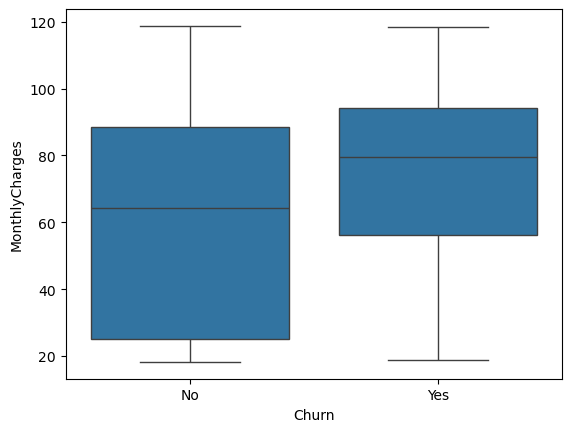

In [27]:

# Compare the distribution of monthly charges between churn groups

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

The visualization shows that churned customers generally have higher monthly charges compared to retained customers.
Observations:

- The median monthly charge is higher for churned customers.
- Customers with higher monthly costs appear more likely to leave.
- Low-cost customers show better retention behavior.

This suggests a possible price sensitivity effect, where customers paying higher amounts may have higher expectations regarding service value

In [28]:
# Improve graph readability by adding a white grid background

sns.set_style("whitegrid")

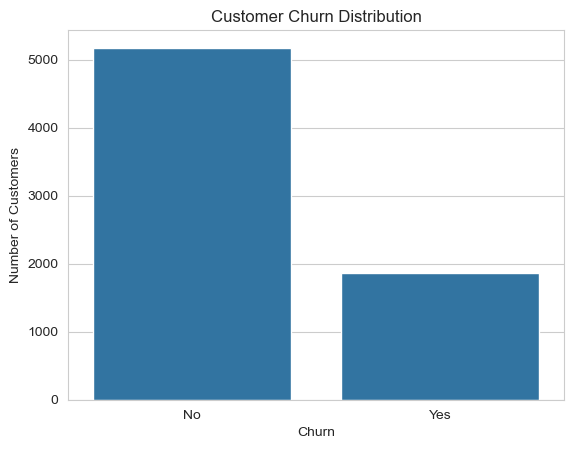

In [29]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

The first visualization shows the overall distribution of customer churn.

The objective is to understand the balance between retained customers
and customers who discontinued their subscription.

# Interpretation

The count plot shows the number of customers in each churn category:

- Churn = No: customers who stayed with the company.
- Churn = Yes: customers who left the company.

The majority of customers are retained, while a smaller proportionhas churned.

# Business Insight

Although churned customers represent a minority of the dataset, they represent a significant business concern because customer loss directly impacts revenue and long-term growth.

The next visualizations will explore which customer characteristics are associated with higher churn risk.

In [30]:
# Calculate churn percentage

churn_pct = df["Churn"].value_counts(normalize=True) * 100

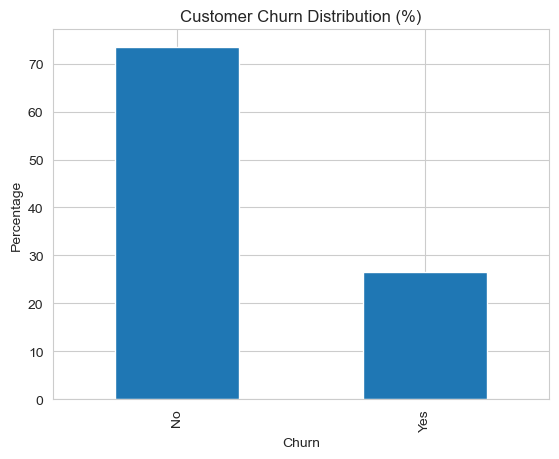

In [31]:
# Create a bar chart

churn_pct.plot(kind="bar")

plt.title("Customer Churn Distribution (%)")
plt.xlabel("Churn")
plt.ylabel("Percentage")

plt.show()

# Interpretation

The churn distribution shows that:

- Approximately 73.5% of customers remained with the company.
- Approximately 26.5%  of customers discontinued their subscription.

# Business Insight

Although churned customers represent a minority of the customer base, a churn rate of around 26.5% is significant and represents a potential revenue loss for the company.
Therefore, identifying the characteristics of churned customers is essential to design targeted retention strategies.

## Contract Distribution:
This visualization shows the distribution of customers across different contract types.
The objective is to understand the customer portfolio structure before analyzing the relationship between contract type and churn.

In [32]:
churn_contract_pct=df["Contract"].value_counts(normalize=True)*100

Text(0, 0.5, 'Percentage')

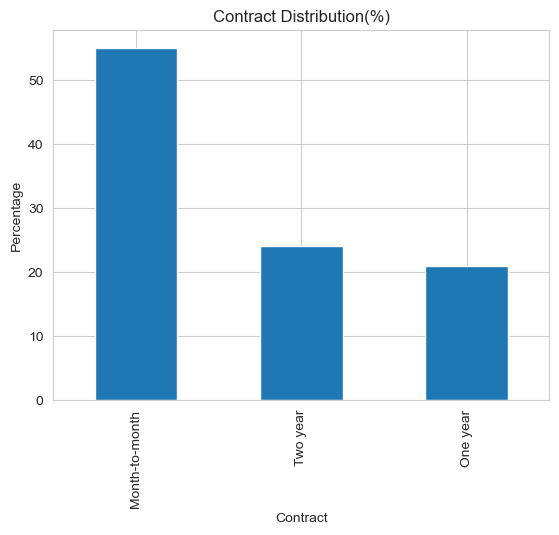

In [33]:
churn_contract_pct.plot(kind="bar")
plt.title("Contract Distribution(%)")
plt.xlabel("Contract")
plt.ylabel("Percentage")

# Interpretation

Most customers are subscribed to month-to-month contracts, while long-term contracts represent a smaller proportion of the customer base.

This distribution is important because contract commitment can influence customer retention behavior.


# Contract Type vs Churn: Churn Analysis by Contract Type
This visualization compares customer churn behavior across different contract types.

The objective is to identify whether contract duration is associated with customer retention.

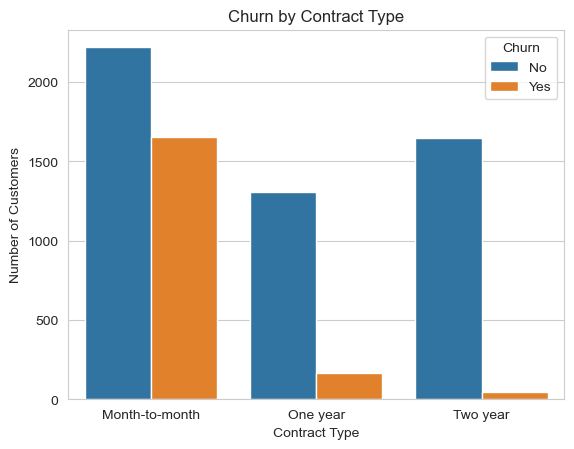

In [34]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

# Interpretation

The visualization highlights a strong relationship between contract type and customer churn.

Observations:

- Month-to-month customers represent the highest churn group.
- Customers with one-year contracts show much better retention.
- Two-year contract customers have the lowest churn level.

# Business Insight

Contract commitment is a major factor influencing customer retention.Customers without long-term commitment are more likely to leave the company, while long-term contracts significantly improve retention.

#  Recommendation

The company should encourage customers to move from month-to-month plans to longer contracts through:

- loyalty programs
- annual subscription discounts
- personalized retention offers

## Churn Analysis by Payment Method

This visualization compares customer churn behavior across different payment methods.

The objective is to identify whether payment method is associated with higher customer churn risk.

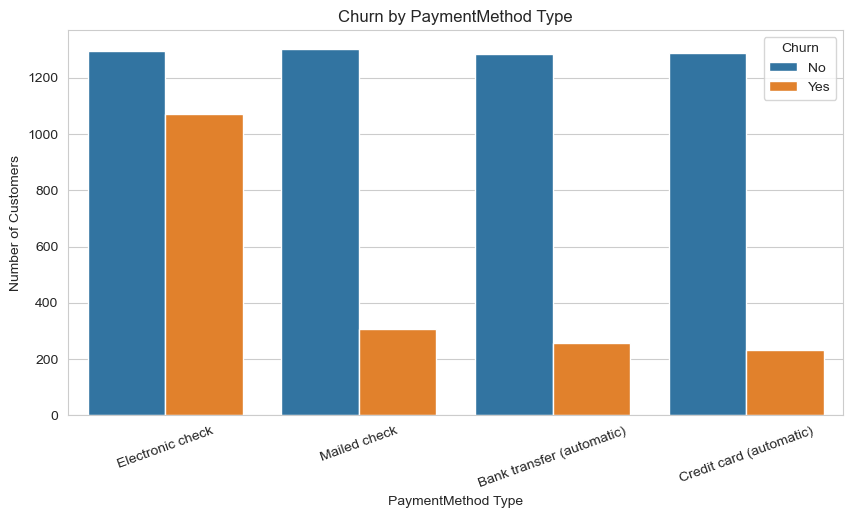

In [35]:
plt.figure(figsize=(10,5))

sns.countplot(x="PaymentMethod", hue="Churn", data=df)

plt.title("Churn by PaymentMethod Type")
plt.xlabel("PaymentMethod Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

# Interpretation
The visualization shows different churn behaviors depending on the payment method.

Observations:

- Customers using Electronic check show the highest number of churned customers compared to other payment methods.
- Customers using automatic payment methods (bank transfer and credit card) show better retention behavior.

# Business Insight

Payment method appears to be associated with customer retention.
Electronic check users represent a higher-risk segment and may require additional investigation.
This pattern could be related to:
- lower customer commitment
- payment friction
- customer dissatisfaction
- different customer profiles

# Recommendation

The company could encourage automatic payment methods by offering:
- easier payment experiences
- incentives for automatic billing
- targeted retention campaigns for electronic check users

Next Analysis: The next step is to analyze churn behavior according to internet service type in order to identify whether service category influences customer retention

## Churn Analysis by Internet Service Type:
This visualization compares customer churn behavior across different internet service categories.

The objective is to determine whether the type of internet service is associated with a higher churn risk.

Text(0, 0.5, 'Number of Customers')

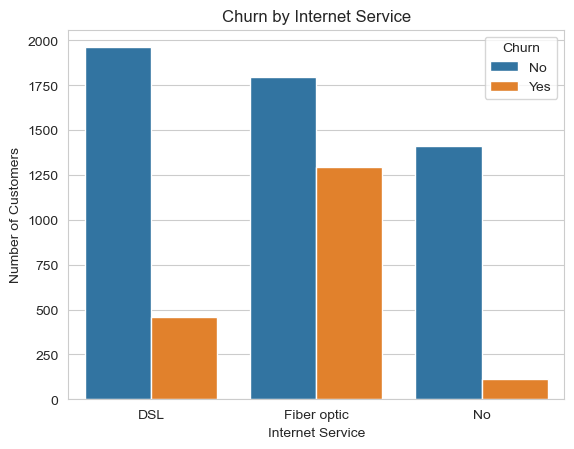

In [36]:
sns.countplot(x="InternetService",hue="Churn", data=df)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

# Interpretation
The visualization shows that churn behavior differs significantly depending on the internet service type.

Important Observations:

- Fiber optic customers show the highest number of churned customers.
- DSL customers have a lower churn level compared to fiber optic users.
- Customers without internet service show the lowest churn behavior.

# Business Insight

Internet service type appears to be an important factor influencing customer churn. Fiber optic customers represent a high-risk segment, which may indicate potential issues related to:
- service quality
- pricing perception
- customer expectations
- competition in premium services

# Recommendation

The company should investigate fiber optic customers by analyzing:
- customer satisfaction;
- technical issues;
- pricing strategy;
- support service usage.
Targeted retention campaigns could be designed for this segment.

# Monthly Charges Distribution by Churn
A box plot is used to compare the distribution of monthly charges between customers who stayed and customers who churned.
The objective is to identify whether customers with higher monthly charges have a higher churn tendency.
Box plots help analyze:
- median values
- data dispersion
- differences between customer groups

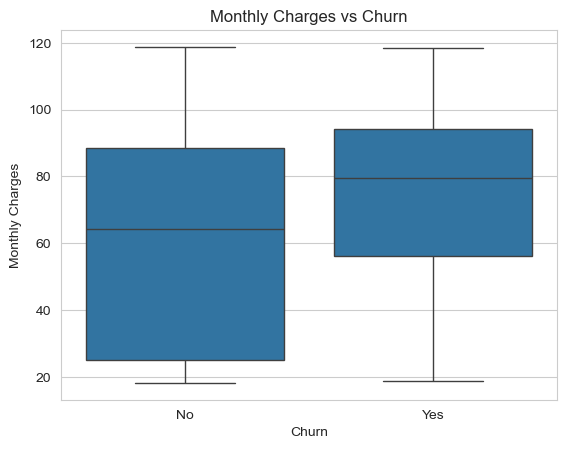

In [37]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

# Interpretation

The box plot shows that customers who churn generally have higher monthly charges compared to customers who stay.
Important observations:

- The median monthly charge is higher for churned customers.
- Customers with lower monthly charges appear more stable.
- Higher-paying customers may have higher expectations regarding service quality and value.

# Business Insight

Monthly charges appear to be associated with customer churn.
High-value customers represent an important retention segment because their departure may generate a significant revenue loss.
However, this relationship does not prove causality. Other factors such as contract type, tenure, and service quality should also be considered.

## Customer Tenure Distribution by Churn:
A box plot is used to compare customer tenure between retained and churned customers.
The objective is to determine whether customer lifetime is related to churn behavior.
This analysis helps identify at which stage of the customer lifecycle churn occurs.

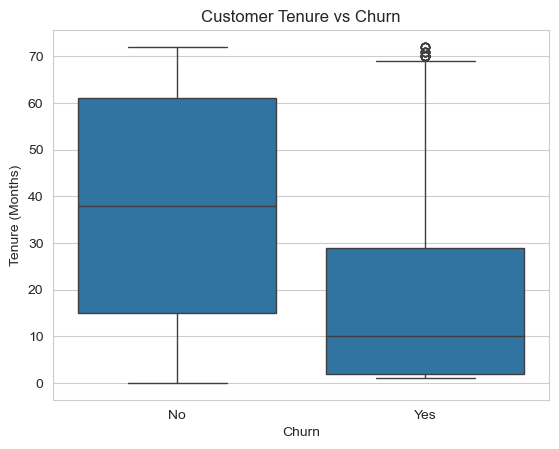

In [38]:
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()


# Interpretation
The box plot highlights a strong difference in customer tenure betweenthe two groups.

Important  observations:
- Churned customers have a much lower median tenure compared to retained customers.
- Most churn events occur during the early customer lifecycle.
- Long-term customers tend to remain more loyal.

# Business Insight

Customer tenure is one of the strongest indicators of churn risk. The company should focus on early customer retention strategies, especially
during the first months after subscription.
Possible actions:

- improve onboarding process
- monitor new customers closely
- provide early loyalty incentives

# Key Findings from Bivariate Analysis

The exploratory analysis identified several important churn drivers:

- Low customer tenure is strongly associated with churn.
- Higher monthly charges are linked to increased churn risk.
- Month-to-month contracts show the highest churn rate.
- Electronic check users represent a high-risk segment.
- Fiber optic customers show higher churn levels.

These findings will guide the feature engineering and machine learning steps.

# Correlation Analysis
Correlation analysis is used to measure the relationship between numerical variables.

The objective is to understand how numeric features interact with each other and identify strong or weak relationships.

Correlation values range from:

- +1 : strong positive relationship
- 0 : no linear relationship
- -1 : strong negative relationship

Only numerical variables are considered because correlation calculations require numeric values.

In [39]:
num_df = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]]
corr = num_df.corr()

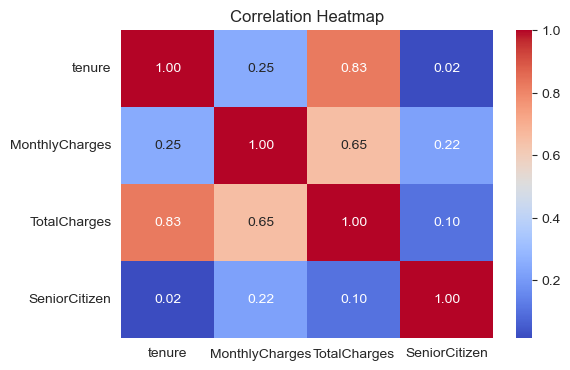

In [40]:
plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# Correlation Insights :The correlation analysis highlights several important relationships:

# 1. tenure and TotalCharges (0.83)

A strong positive correlation exists between customer tenure and total charges. This is expected because customers who stay longer accumulate more charges over time.

# 2. MonthlyCharges and TotalCharges (0.65)

Customers with higher monthly payments tend to generate higher total revenue.

# 3. tenure and MonthlyCharges (0.25)

The relationship is weak, meaning that older customers do not necessarily payhigher monthly charges.

# 4. SeniorCitizen impact

SeniorCitizen shows weak correlations with other numerical variables, suggesting that age status has limited influence on these numerical behaviors.

# Customer Segmentation by Monthly Charges
To improve business interpretation, monthly charges were transformed into
three customer segments:
- Low charges
- Medium charges
- High charges

This segmentation helps identify whether high-value customers represent a higher churn risk.

In [41]:
df["ChargeLevel"] = pd.cut(df["MonthlyCharges"], bins=[0, 35, 70, 120], labels=["Low", "Medium", "High"])

pd.crosstab(df["ChargeLevel"], df["Churn"], normalize="index")*100


Churn,No,Yes
ChargeLevel,,
Low,89.106628,10.893372
Medium,76.057971,23.942029
High,64.638571,35.361429


# Business Insight

The analysis shows a clear relationship between charge level and churn risk.

- Low-charge customers have the lowest churn rate (11%).
- Medium-charge customers show an intermediate churn rate (24%).
- High-charge customers have the highest churn rate (35%).

High-value customers generate more revenue but also represent a critical retention risk. Targeted retention strategies should focus on customers with high monthly charges.

# Customer Segmentation by Tenure

Customer tenure was divided into three groups to analyze churn behavior throughout the customer lifecycle:

- New customers (0-12 months)
- Mid customers (12-36 months)
- Old customers (36-72 months)

This segmentation helps identify the periods where customers are most likely to leave.

In [42]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[0,12,36,72], labels=["New","Mid","Old"])

pd.crosstab(df["TenureGroup"], df["Churn"], normalize="index")*100


Churn,No,Yes
TenureGroup,,
New,52.321839,47.678161
Mid,74.461207,25.538793
Old,88.070643,11.929357


# Business Insight

The analysis reveals a strong relationship between customer tenure and churn.
Importatnt  observations:

- New customers show the highest churn rate (48%).
- Mid-term customers have a moderate churn rate (26%).
- Long-term customers are the most loyal segment, with only 12% churn.

The first year represents the most critical period in the customer lifecycle. Customers who successfully pass this stage are much more likely to remain with the company.

# Recommendations
Since churn is concentrated among new customers, the company should focus on:
- improving customer onboarding during the first months;
- monitoring customer satisfaction early;
- providing loyalty incentives during the first year;
- identifying early warning signals before customer departure.

In [43]:
df["ChurnFlag"] = df["Churn"].map({"No": 0, "Yes": 1})

In [44]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'ChargeLevel', 'TenureGroup', 'ChurnFlag'],
      dtype='object')

In [45]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   object  
 1   gender            7043 non-null   object  
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   object  
 4   Dependents        7043 non-null   object  
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   object  
 7   MultipleLines     7043 non-null   object  
 8   InternetService   7043 non-null   object  
 9   OnlineSecurity    7043 non-null   object  
 10  OnlineBackup      7043 non-null   object  
 11  DeviceProtection  7043 non-null   object  
 12  TechSupport       7043 non-null   object  
 13  StreamingTV       7043 non-null   object  
 14  StreamingMovies   7043 non-null   object  
 15  Contract          7043 non-null   object  
 16  PaperlessBilling  7043 n

In [46]:
df.to_excel("telco_clean.xlsx", index=False)

In [47]:
df.to_csv("telco_clean.csv", index=False)